In [19]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"

import jax
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Pyramid
import pyramid as pr
from pyramid.fielddata import VectorData
from pyramid.projector import SimpleProjector
from pyramid.phasemapper import PhaseMapperRDFC
from pyramid.phasemap import PhaseMap
from pyramid.kernel import Kernel
from pyramid.utils.convenience import reconstruction_2d_from_phasemap

# LiberTEM-holo
from libertem_holo.base.shapes import create_mag_dist_homog, disc
from libertem_holo.base.mbir import (
    add_units_to_inputs,
    forward_model_2d,
    lcurve_sweep_vmap,
    make_quantity,
    plot_lcurve,
    reconstruct_2d,
    to_local_induction,
    to_local_magnetization,
    to_projected_induction_integral,
    to_projected_magnetization_integral,
)

jax.config.update("jax_enable_x64", True)

%matplotlib widget


# Synthetic Magnetisation Reconstruction with Pyramid
This notebook demonstrates the workflow for generating a synthetic magnetisation distribution, simulating phase maps, and reconstructing the magnetisation using the Pyramid library, and comparing the result to libertem-empyre mbir. 

---


## 0. Setup test object parameters

In [20]:
N = 128
dim = (N, N, N)
center = (N // 2, N // 2, N // 2)

quantity_inputs = add_units_to_inputs(
    pixel_size=7.423,
    pixel_size_unit="nm",
    thickness=125.0,
    thickness_unit="nm",
)
pixel_size = quantity_inputs["pixel_size"]
thickness_physical = quantity_inputs["thickness"]
local_induction = make_quantity(0.124215, "T")  # reference induction used by MBIR (1 T)

radius_physical = make_quantity(300.0, "nm")
radius_pixels = int(round(float((radius_physical / pixel_size).value)))
height_pixels = int(round(float((thickness_physical / pixel_size).value)))

R = make_quantity(radius_pixels, "pixel")
H = make_quantity(height_pixels, "pixel")
mag_shape = disc(dim=dim, center=center, radius=R, height=H)

mag_unit = create_mag_dist_homog(mag_shape=mag_shape, phi=np.pi / 2)
induction_scale = float(local_induction.value)
disc_uni = induction_scale * mag_unit
max_iter = 5000

print(
    f"Radius: {float(radius_physical.value):.1f} {radius_physical.unit} -> {radius_pixels} px | "
    f"Thickness: {float(thickness_physical.value):.1f} {thickness_physical.unit} -> {height_pixels} px | "
    f"Local induction: {float(local_induction.value):.3f} {local_induction.unit}"
)


Radius: 300.0 nm -> 40 px | Thickness: 125.0 nm -> 17 px | Local induction: 0.124 T


## 1. Create Synthetic Magnetisation Distribution
Make the magnetic distribution for pyramid. 

In [21]:
mag_distrib = VectorData(a=float(pixel_size.value), field=disc_uni)

### Visualize Magnetisation Components
Display the three components of the synthetic magnetisation in the central slice.

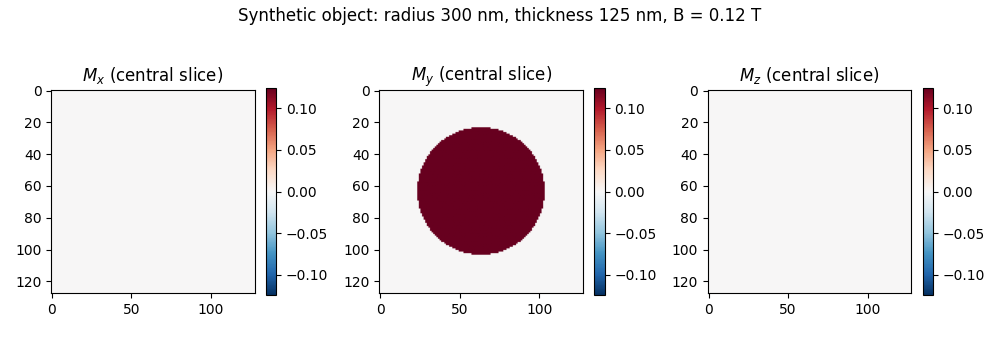

In [22]:
 



fig, ax = plt.subplots(ncols=3, figsize=(10, 3.5))

component_abs_max = max(np.abs(mag_distrib.field).max(), 1e-12)

im = ax[0].imshow(
    mag_distrib.field[0].sum(axis=0),
    cmap="RdBu_r",
    vmin=-component_abs_max,
    vmax=component_abs_max,
 )
ax[0].set_title("$M_x$ (central slice)")
plt.colorbar(im, ax=ax[0], fraction=0.046)

im = ax[1].imshow(
    mag_distrib.field[1].sum(axis=0),
    cmap="RdBu_r",
    vmin=-component_abs_max,
    vmax=component_abs_max,
 )
ax[1].set_title("$M_y$ (central slice)")
plt.colorbar(im, ax=ax[1], fraction=0.046)

im = ax[2].imshow(
    mag_distrib.field[2].sum(axis=0),
    cmap="RdBu_r",
    vmin=-component_abs_max,
    vmax=component_abs_max,
 )
ax[2].set_title("$M_z$ (central slice)")
plt.colorbar(im, ax=ax[2], fraction=0.046)

fig.suptitle(
    f"Synthetic object: radius {float(radius_physical.value):.0f} nm, "
    f"thickness {float(thickness_physical.value):.0f} nm, "
    f"B = {float(local_induction.value):.2f} T"
 )
plt.tight_layout()

In [23]:
projector = SimpleProjector(mag_distrib.dim, axis='z')
kern = Kernel(mag_distrib.a, projector.dim_uv, geometry="disc")
phasemapper = PhaseMapperRDFC(kern)
field_proj = projector(mag_distrib)
phasemap = phasemapper(field_proj)
phasemap.mask = field_proj.get_mask()[0, ...]

## 2. Simulate Phase Map
Project the synthetic magnetisation and simulate the phase map using the forward model.

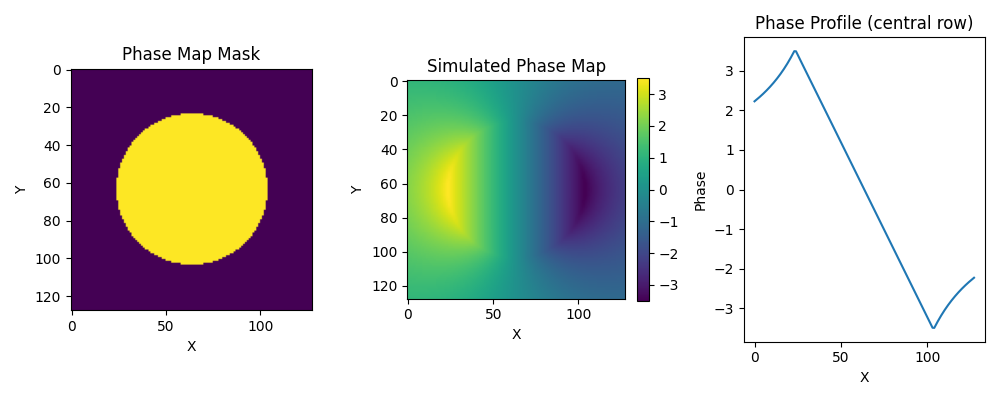

In [24]:
fig, ax = plt.subplots(ncols=3, figsize=(10,4))

ax[0].imshow(phasemap.mask)
ax[0].set_title("Phase Map Mask")
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")

im1 = ax[1].imshow(phasemap.phase)
ax[1].set_title("Simulated Phase Map")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")
plt.colorbar(im1, ax=ax[1], fraction=0.046)

ax[2].plot(phasemap.phase[N//2, ...])
ax[2].set_title("Phase Profile (central row)")
ax[2].set_xlabel("X")
ax[2].set_ylabel("Phase")

plt.tight_layout()

### Visualize Phase Map and Mask
Show the simulated phase map and the mask used for further processing.

In [25]:
phase_mag = phasemap.phase
phase_mip = phasemap.mask

Mask covers 5024 / 16384 pixels (30.7%)


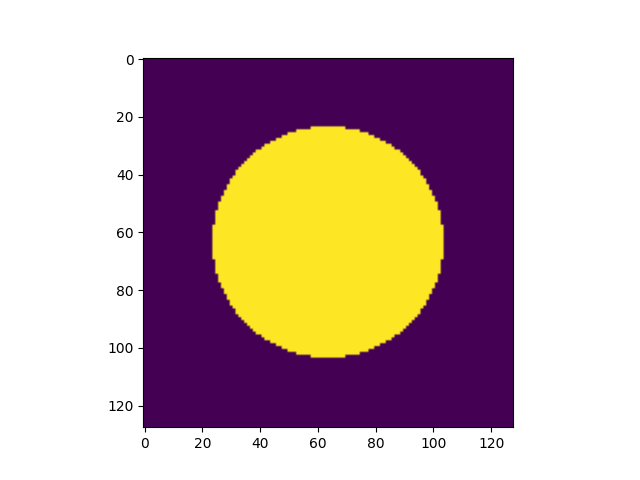

In [26]:
mip_threshold = 0.1
mask = (np.abs(phase_mip) > mip_threshold).astype(np.float64)
plt.figure()
plt.imshow(mask)
print(f"Mask covers {mask.sum():.0f} / {mask.size} pixels "
      f"({100 * mask.mean():.1f}%)")

phasemap = pr.PhaseMap(a=mag_distrib.a, phase=phase_mag, mask=mask)
dim = (1,) + phasemap.dim_uv

# Pass the disc mask to DataSet so Pyramid optimizes only inside the disc,
# matching MBIR's `mag * mask` behaviour.  Without this, Pyramid defaults to
# an all-True mask (full grid) which gives very different L-curve values.
mask_3d = mask.astype(bool)[None, ...]  # shape (1, H, W)
data_set = pr.DataSet(phasemap.a, dim=dim, mask=mask_3d)

# Pass a PhaseMapperRDFC explicitly so Pyramid's ForwardModel uses the same
# forward model as MBIR (zero-padded linear convolution, not periodic FDFC).
kern_pyr_rdfc = Kernel(mag_distrib.a, phasemap.dim_uv, geometry="disc")
phasemapper_rdfc = PhaseMapperRDFC(kern_pyr_rdfc)
data_set.append(phasemap, pr.SimpleProjector(dim=dim), phasemapper=phasemapper_rdfc)

## 3. Forward Model and L-Curve Analysis
Set up the forward model and perform L-curve analysis to select the regularization parameter.

  0%|          | 0/5 [00:00<?, ?it/s]

<Axes: xlabel='$\\Vert\\mathbf{F}(\\mathbf{x})-\\mathbf{y}\\Vert_{\\mathbf{S}_{\\epsilon}^{-1}}^{2}$', ylabel='$\\frac{1}{\\lambda}\\Vert\\mathbf{x}\\Vert_{\\mathbf{S}_{a}^{-1}}^{2}$'>

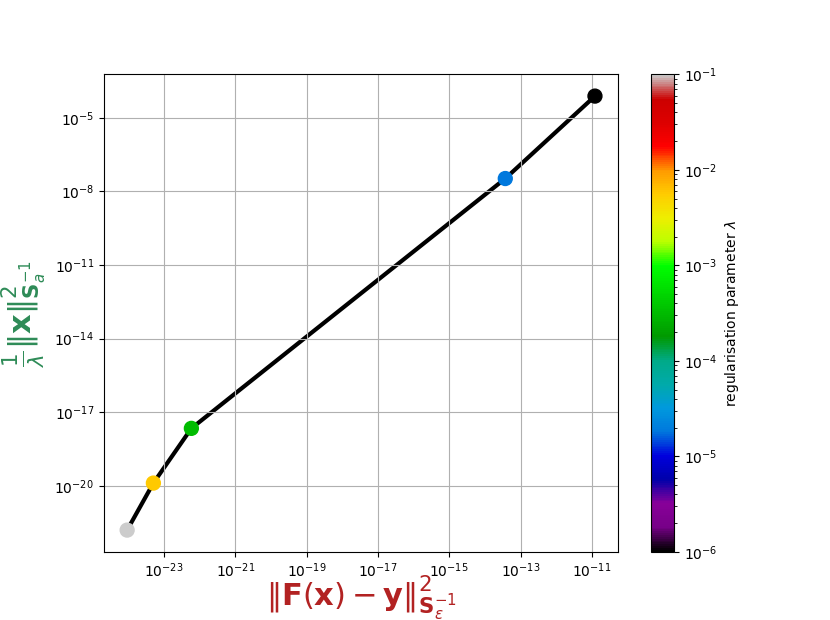

In [27]:
ramp_order = 1
fwd_model = pr.ForwardModel(data_set, ramp_order=ramp_order)

lambdas = np.logspace(-6, -1, num=5)
lcurve = pr.LCurve(fwd_model, max_iter=max_iter)

lcurve.calculate(lambdas)

x_lcurve_pyramid = [lcurve.l_dict[lam][0] for lam in lambdas]
y_lcurve_pyramid = [lcurve.l_dict[lam][1] / lam for lam in lambdas]

lcurve.plot(lambdas)

The L-curve looks bizarre because there is no noise. 

## 5. 2D Reconstruction from Phase Map
Use the selected regularization parameter to reconstruct the 2D magnetisation distribution from the phase map.
Arbitrarily select the best lambda since it is not so important. 

In [28]:
best_lam = 1e-4

pm = PhaseMap(a=mag_distrib.a, phase=np.asarray(phase_mag), mask=mask)
magdata_pyr, cost_pyr = reconstruction_2d_from_phasemap(
    pm, lam=best_lam, max_iter=max_iter,
    ramp_order=None, verbose=True,
    )

CG:   0%|          | 0/5000 [00:00<?, ?it/s]

In [29]:
u_pyr = magdata_pyr.field[0,0,...]
v_pyr = magdata_pyr.field[1,0,...]
mag_abs_pyr = magdata_pyr.field_amp[0,...]

### Extract Magnetisation Components
Extract the reconstructed $M_x$, $M_y$, and $|M|$ components from the result.

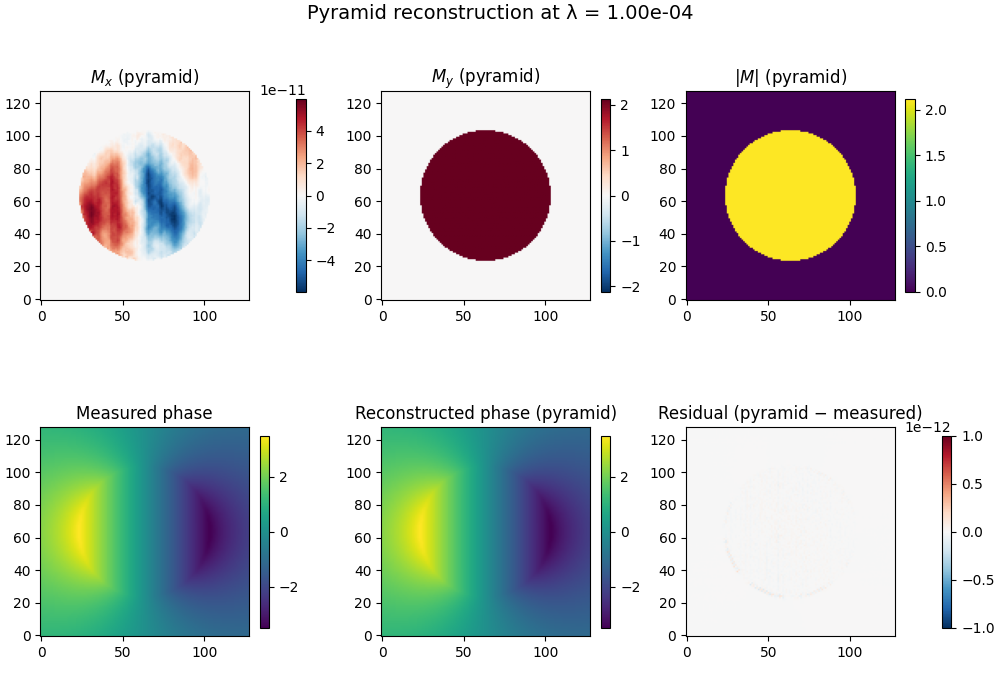

Pyramid residual RMS: 0.000000


In [30]:
# Forward-model pyramid's reconstruction to get the predicted phase
kern_pyr = Kernel(mag_distrib.a, phase_mag.shape, geometry="disc")
mapper_pyr = PhaseMapperRDFC(kern_pyr)
field_pyr = np.zeros((3, 1) + phase_mag.shape)
field_pyr[0, 0] = u_pyr
field_pyr[1, 0] = v_pyr
pred_pyr = mapper_pyr(VectorData(mag_distrib.a, field_pyr)).phase
residual_pyr = pred_pyr - phase_mag

fig, axs = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)

# Row 1: magnetisation components
vmax_u = max(np.abs(u_pyr).max(), 1e-12)
vmax_v = max(np.abs(v_pyr).max(), 1e-12)

im = axs[0, 0].imshow(u_pyr, cmap="RdBu_r", origin="lower",
                      norm=TwoSlopeNorm(0, -vmax_u, vmax_u))
axs[0, 0].set_title(r"$M_x$ (pyramid)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(v_pyr, cmap="RdBu_r", origin="lower",
                      norm=TwoSlopeNorm(0, -vmax_v, vmax_v))
axs[0, 1].set_title(r"$M_y$ (pyramid)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[0, 2].imshow(mag_abs_pyr, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (pyramid)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

# Row 2: phase comparison
vmin_p = min(np.nanmin(phase_mag), np.nanmin(pred_pyr))
vmax_p = max(np.nanmax(phase_mag), np.nanmax(pred_pyr))

im = axs[1, 0].imshow(phase_mag, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(pred_pyr, cmap="viridis", origin="lower", vmin=vmin_p, vmax=vmax_p)
axs[1, 1].set_title("Reconstructed phase (pyramid)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)

dmax_p = max(np.abs(residual_pyr).max(), 1e-12)
im = axs[1, 2].imshow(residual_pyr, cmap="RdBu_r", origin="lower", vmin=-dmax_p, vmax=dmax_p)
axs[1, 2].set_title("Residual (pyramid − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(f"Pyramid reconstruction at λ = {best_lam:.2e}", fontsize=14)
plt.show()

print(f"Pyramid residual RMS: {np.sqrt(np.mean(residual_pyr**2)):.6f}")


Small numerical artefacts are present that don't matter. Pyramid reconstruction is good, but it's not clear what units come out - Pyramid says it calculates magnetisation, but 
the units are not A/m - it is a unitless magnetisation. This is not entirely clear. 

## 7. MBIR Solution with LiberTEM-holo
Now we reconstruct the magnetisation using the MBIR method from `libertem_holo.base.mbir` and compare it to the Pyramid solution. With libertem holo, we pass a phase with units of radians, and a pixel size with units of nanometres, and we can inspect the units of the output object. 

Before we show that, we run a lambda curve analysis again to select the regularization parameter, and then we run the reconstruction.

In [32]:
lambdas_mbir = np.logspace(-6, 3, num=20)
mbir_inputs = add_units_to_inputs(
    phase=phase_mag,
    pixel_size=float(pixel_size.value),
 )
phase = mbir_inputs["phase"]
lc_mbir = lcurve_sweep_vmap(
    phase=phase,
    mask=mask,
    pixel_size=pixel_size,
    lambdas=lambdas_mbir,
    solver="newton_cg",
)

corner_lambda = lc_mbir.lambdas[lc_mbir.corner_index]
print(
    f"MBIR L-curve corner: index {lc_mbir.corner_index} "
    f"(lambda = {float(corner_lambda.value):.3e})"
 )

MBIR L-curve corner: index 12 (lambda = 4.833e-01)


Again lambda curve is not so great as there is no noise. Our lambda curve looks different because we use a slightly different regulariser (which uses a different gradient - central difference in the centre and forward difference at the edges). 

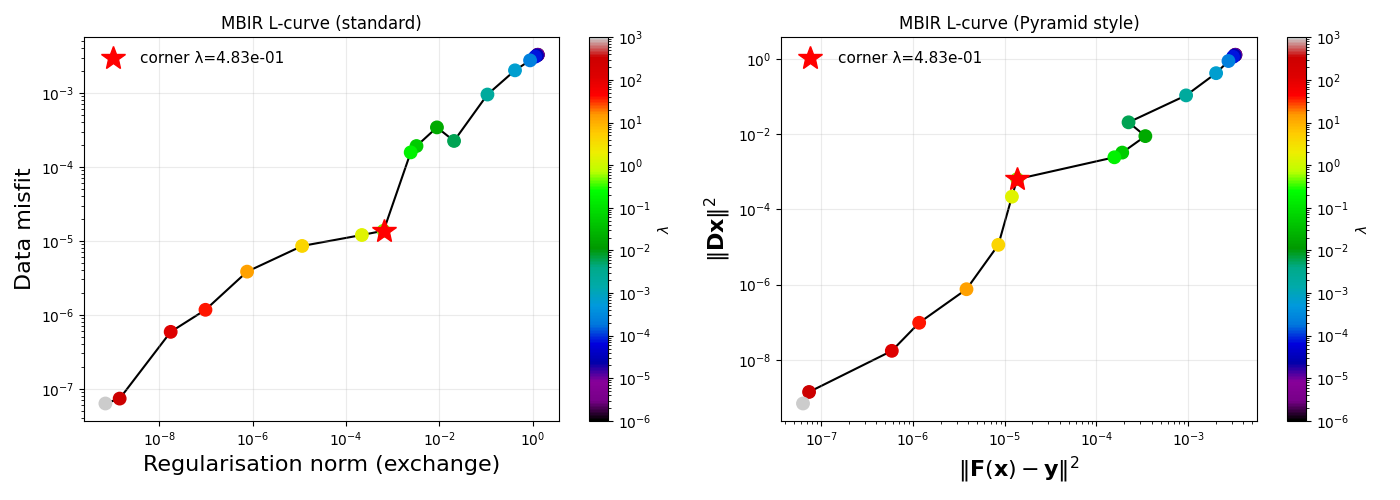

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
plot_lcurve(lc_mbir, pyramid_style=False, ax=axs[0])
axs[0].set_title("MBIR L-curve (standard)")
plot_lcurve(lc_mbir, pyramid_style=True, ax=axs[1])
axs[1].set_title("MBIR L-curve (Pyramid style)")
plt.tight_layout()
plt.show()


At least both of the l curves in pyramid and libertem follow a similar trend. 

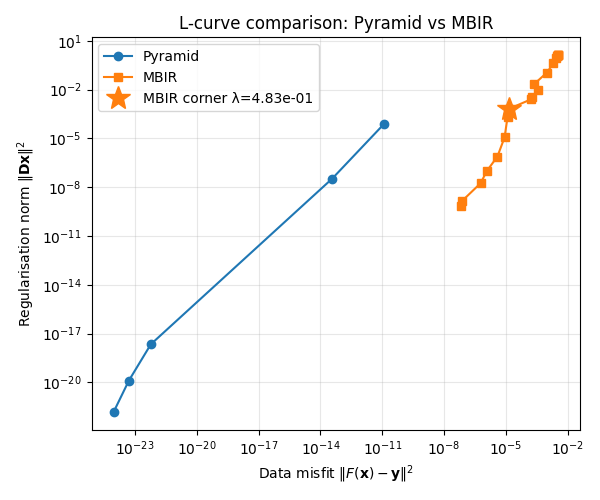

In [34]:
# --- Overlay L-curve comparison: Pyramid vs MBIR ---
fig, ax = plt.subplots(figsize=(6, 5))

mbir_data_misfits = lc_mbir.data_misfits.value
mbir_reg_norms = lc_mbir.reg_norms.value
mbir_lambdas = lc_mbir.lambdas.value

# Pyramid L-curve (x = data misfit, y = reg norm)
ax.loglog(x_lcurve_pyramid, y_lcurve_pyramid, 'o-', color='tab:blue', label='Pyramid')

# MBIR L-curve (reported reg norm uses exchange_loss_fn)
ax.loglog(mbir_data_misfits, mbir_reg_norms, 's-', color='tab:orange', label='MBIR')

# Mark corners
corner_idx_pyr = lcurve.corner_idx if hasattr(lcurve, 'corner_idx') else None
corner_idx_mbir = lc_mbir.corner_index

if corner_idx_mbir is not None:
    ax.plot(
        mbir_data_misfits[corner_idx_mbir],
        mbir_reg_norms[corner_idx_mbir],
        '*',
        ms=18,
        color='tab:orange',
        zorder=5,
        label=f'MBIR corner λ={mbir_lambdas[corner_idx_mbir]:.2e}'
    )

ax.set_xlabel(r'Data misfit $\|F(\mathbf{x}) - \mathbf{y}\|^2$')
ax.set_ylabel(r'Regularisation norm $\|\mathbf{Dx}\|^2$')
ax.set_title('L-curve comparison: Pyramid vs MBIR')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


## 8. Visualize LiberTEM-holo Reconstruction
Reconstruct with the MBIR corner lambda and plot the recovered projected magnetisation together with the predicted phase and residual.
We can inspect the unit of the reconstructed magnetisation, and it is unitless. This is because the computation is non-dimensionalised by the flux quantum. 

Output unit: (Should be empty to represent the non-dimensional case) 
Best MBIR lambda: 4.833e-01
Projected |M| mean inside mask: 2.1117
Projected |M| max inside mask:  2.1117
MBIR residual RMS: 0.000000


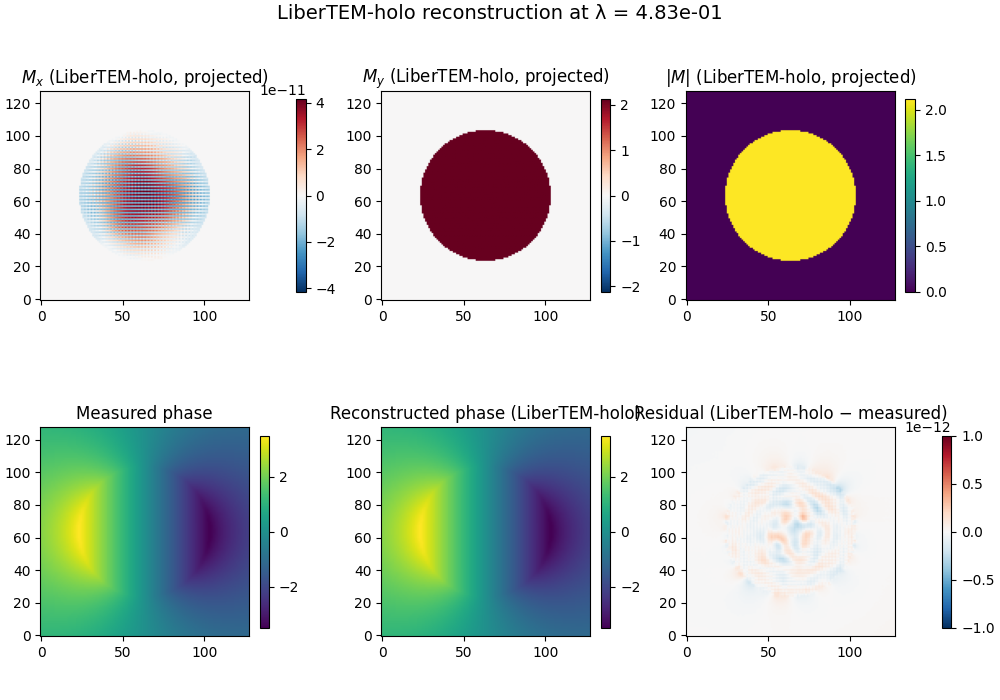

In [54]:
best_lam_mbir = lc_mbir.lambdas[lc_mbir.corner_index]
from libertem_holo.base.mbir.solver import NewtonCGConfig

config = NewtonCGConfig(cg_maxiter=1000000, cg_tol=1e-15, preconditioner='block_jacobi')
result_mbir = reconstruct_2d(
    phase=phase,
    pixel_size=pixel_size,
    mask=mask,
    lam=best_lam_mbir,
    solver=config,
)

print("Output unit: (Should be empty to represent the non-dimensional case)", result_mbir.magnetization.unit)

best_mag_mbir = result_mbir.magnetization.value
mx_mbir = best_mag_mbir[..., 0]
my_mbir = best_mag_mbir[..., 1]
mag_norm_mbir = np.sqrt(mx_mbir**2 + my_mbir**2)

pred_phase_mbir = forward_model_2d(
        result_mbir.magnetization,
        pixel_size,
        ramp_coeffs=result_mbir.ramp_coeffs,
).value

residual_mbir = pred_phase_mbir - phase_mag

inside = mask > 0.5
print(f"Best MBIR lambda: {float(best_lam_mbir.value):.3e}")
print(f"Projected |M| mean inside mask: {mag_norm_mbir[inside].mean():.4f}")
print(f"Projected |M| max inside mask:  {mag_norm_mbir[inside].max():.4f}")
print(f"MBIR residual RMS: {np.sqrt(np.mean(residual_mbir**2)):.6f}")

fig, axs = plt.subplots(2, 3, figsize=(10, 7), constrained_layout=True)

vmax_mx = max(np.abs(mx_mbir).max(), 1e-12)
vmax_my = max(np.abs(my_mbir).max(), 1e-12)

im = axs[0, 0].imshow(
    mx_mbir,
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0, -vmax_mx, vmax_mx),
)
axs[0, 0].set_title(r"$M_x$ (LiberTEM-holo, projected)")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046)

im = axs[0, 1].imshow(
    my_mbir,
    cmap="RdBu_r",
    origin="lower",
    norm=TwoSlopeNorm(0, -vmax_my, vmax_my),
)
axs[0, 1].set_title(r"$M_y$ (LiberTEM-holo, projected)")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046)

im = axs[0, 2].imshow(mag_norm_mbir, cmap="viridis", origin="lower")
axs[0, 2].set_title(r"$|M|$ (LiberTEM-holo, projected)")
plt.colorbar(im, ax=axs[0, 2], fraction=0.046)

vmin_m = min(np.nanmin(phase_mag), np.nanmin(pred_phase_mbir))
vmax_m = max(np.nanmax(phase_mag), np.nanmax(pred_phase_mbir))

im = axs[1, 0].imshow(
    phase_mag,
    cmap="viridis",
    origin="lower",
    vmin=vmin_m,
    vmax=vmax_m,
 )
axs[1, 0].set_title("Measured phase")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046)

im = axs[1, 1].imshow(
    pred_phase_mbir,
    cmap="viridis",
    origin="lower",
    vmin=vmin_m,
    vmax=vmax_m,
 )
axs[1, 1].set_title("Reconstructed phase (LiberTEM-holo)")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046)

dmax_m = max(np.abs(residual_mbir).max(), 1e-12)
im = axs[1, 2].imshow(
    residual_mbir,
    cmap="RdBu_r",
    origin="lower",
    vmin=-dmax_m,
    vmax=dmax_m,
 )
axs[1, 2].set_title("Residual (LiberTEM-holo − measured)")
plt.colorbar(im, ax=axs[1, 2], fraction=0.046)

fig.suptitle(
    f"LiberTEM-holo reconstruction at λ = {float(best_lam_mbir.value):.2e}",
    fontsize=14,
 )
plt.show()

Again some small numerical artefacts, but we have the same result. 

## Physical scaling of the MBIR reconstruction

Convert the normalized projected magnetization into a projected induction line integral in T nm and a projected magnetization line integral in A.

Then divide both projected line integrals by the known physical thickness to obtain thickness-averaged local quantities in T and A/m.

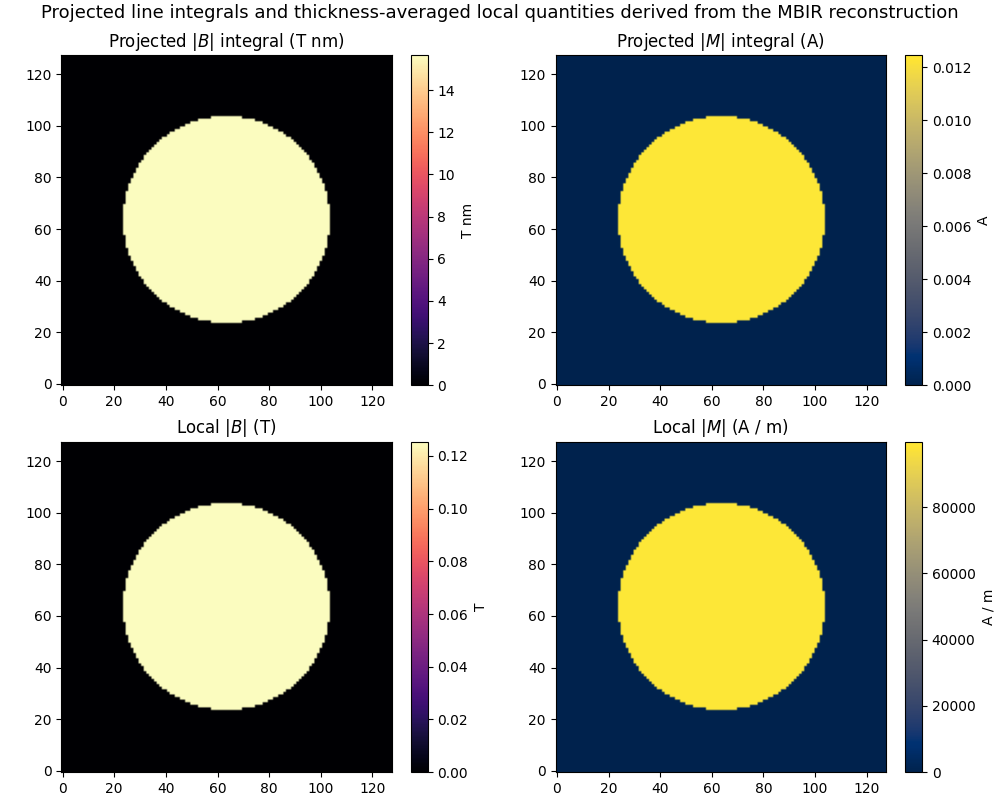

Expected projected peak |B| integral ≈ H * a * B_local = 15.824 T nm
Observed projected peak |B| integral = 15.675 T nm
Peak projected magnetization integral: 0.012 A
Peak local induction: 0.125399 T
Peak local magnetization: 99788.980021 A / m


In [39]:
projected_induction_integral = to_projected_induction_integral(
    result_mbir.magnetization,
    pixel_size,
 )
projected_magnetization_integral = to_projected_magnetization_integral(
    result_mbir.magnetization,
    pixel_size,
 )
local_induction = to_local_induction(
    projected_induction_integral,
    thickness_physical,
 )
local_magnetization = to_local_magnetization(
    projected_magnetization_integral,
    thickness_physical,
 )

projected_induction_integral_norm = np.linalg.norm(np.asarray(projected_induction_integral.value), axis=-1)
projected_magnetization_integral_norm = np.linalg.norm(np.asarray(projected_magnetization_integral.value), axis=-1)
local_induction_norm = np.linalg.norm(np.asarray(local_induction.value), axis=-1)
local_mag_norm = np.linalg.norm(np.asarray(local_magnetization.value), axis=-1)

expected_projected_peak = float(H.value) * float(pixel_size.value) * float(np.max(local_induction.value))
observed_projected_peak = float(np.nanmax(projected_induction_integral_norm))

fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

im = axs[0, 0].imshow(projected_induction_integral_norm, cmap="magma", origin="lower")
axs[0, 0].set_title(rf"Projected $|B|$ integral ({projected_induction_integral.unit})")
plt.colorbar(im, ax=axs[0, 0], fraction=0.046, label=projected_induction_integral.unit)

im = axs[0, 1].imshow(projected_magnetization_integral_norm, cmap="cividis", origin="lower")
axs[0, 1].set_title(rf"Projected $|M|$ integral ({projected_magnetization_integral.unit})")
plt.colorbar(im, ax=axs[0, 1], fraction=0.046, label=projected_magnetization_integral.unit)

im = axs[1, 0].imshow(local_induction_norm, cmap="magma", origin="lower")
axs[1, 0].set_title(rf"Local $|B|$ ({local_induction.unit})")
plt.colorbar(im, ax=axs[1, 0], fraction=0.046, label=local_induction.unit)

im = axs[1, 1].imshow(local_mag_norm, cmap="cividis", origin="lower")
axs[1, 1].set_title(rf"Local $|M|$ ({local_magnetization.unit})")
plt.colorbar(im, ax=axs[1, 1], fraction=0.046, label=local_magnetization.unit)

fig.suptitle(
    "Projected line integrals and thickness-averaged local quantities derived from the MBIR reconstruction",
    fontsize=13,
 )
plt.show()

print(f"Expected projected peak |B| integral ≈ H * a * B_local = {expected_projected_peak:.3f} {projected_induction_integral.unit}")
print(f"Observed projected peak |B| integral = {observed_projected_peak:.3f} {projected_induction_integral.unit}")
print(
    f"Peak projected magnetization integral: {float(np.nanmax(projected_magnetization_integral_norm)):.3f} {projected_magnetization_integral.unit}"
 )
print(
    f"Peak local induction: {float(np.nanmax(local_induction_norm)):.6f} {local_induction.unit}"
 )
print(
    f"Peak local magnetization: {float(np.nanmax(local_mag_norm)):.6f} {local_magnetization.unit}"
 )